In [61]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly as plty
import yfinance

Data Collection and Feature Engineering 

In [62]:
df = pd.read_csv('data/Inflation_CPI.csv')
df["DATE"] = pd.to_datetime(df["DATE"])
df

,DATE,CPIAUCSL
0,2010-01-01,217.488
1,2010-02-01,217.281
2,2010-03-01,217.353
3,2010-04-01,217.403
4,2010-05-01,217.290
...,...,...
176,2024-09-01,314.732
177,2024-10-01,315.631
178,2024-11-01,316.528
179,2024-12-01,317.604


Inflation means the general increase in prices of goods and services over time. 
If Inflation rises -> The Money buys less

The Consumer Price Index (CPI) is statistical measure used to track inflation.
It measures how the prices of a fixed basket of goods and services changes over time.


In [63]:
df.describe()

,DATE,CPIAUCSL
count,181,181.000000
mean,2017-07-01 13:07:37.458563584,254.490768
min,2010-01-01 00:00:00,217.199000
25%,2013-10-01 00:00:00,233.669000
50%,2017-07-01 00:00:00,244.243000
75%,2021-04-01 00:00:00,266.614000
max,2025-01-01 00:00:00,318.961000
std,NaN,28.786628


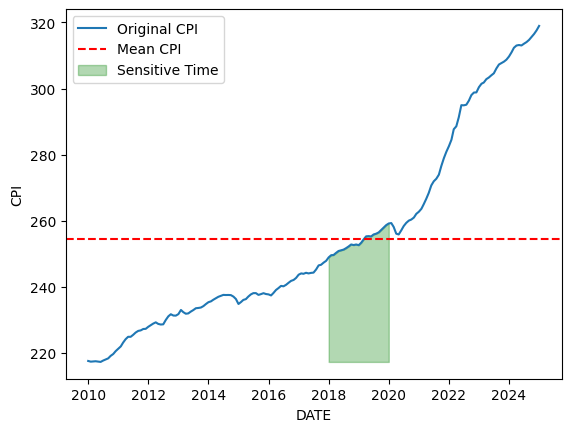

In [64]:
x = df["CPIAUCSL"].values
y = df["DATE"].values

x_mean = df["CPIAUCSL"].values.mean()
x_std = df["CPIAUCSL"].values.std()

mask = (df['DATE'] >= "2018-01-01") & (df["DATE"] <= "2020-01-01")

y_min = min(x)

plt.plot(y,x,label = "Original CPI")
plt.axhline(x_mean, color= 'r', linestyle = '--', label = "Mean CPI")
# plt.plot(y_n,x_n, color = 'g', alpha = 0.5, linestyle = "-", label = "Sensitive Area")
plt.fill_between(
    y,x,
    y_min,
    where = mask,
    color = 'green',
    alpha = 0.3,
    label = "Sensitive Time"
)
plt.xlabel("DATE")
plt.legend()
plt.ylabel("CPI")
plt.show()

In [65]:
df1 = pd.read_csv("data/APPLE.csv")
df1

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,6.412384510040283,6.427066322741706,6.363544880017381,6.395005964384629,493729600
3,2010-01-05,6.423468589782715,6.459723852019821,6.389610022526822,6.430060601116457,601904800
4,2010-01-06,6.321296215057373,6.44893875336688,6.314704202262994,6.423470013074288,552160000
...,...,...,...,...,...,...
3771,2024-12-24,256.7972106933594,256.80713572411884,253.90300191480816,254.10192745486222,23234700
3772,2024-12-26,257.6127014160156,258.6868506395932,256.2302692406472,256.7872242633273,27237100
3773,2024-12-27,254.2013702392578,257.29448932345014,251.68511699924173,256.42919055718573,42355300
3774,2024-12-30,250.82980346679688,252.122743648892,249.38768429964367,250.8596392638085,35557500


In [66]:
df1.describe()

,Price,Close,High,Low,Open,Volume
count,3776,3775,3775,3775,3775,3775
unique,3776,3723,3775,3775,3775,3766
top,2024-12-06,26.274696350097656,251.90392569582917,248.07483671879714,251.0684930674946,391638800
freq,1,2,1,1,1,2


In [67]:
df1.rename(columns={'Price': 'Date'}, inplace = True)
df1.isnull().sum()
# df1.remove(None)
df1 =df1.dropna()
df1 = df1.drop_duplicates()
df1.reset_index(inplace = True, drop = True)
df1['Date'] = pd.to_datetime(df1['Date'],errors = 'coerce')

df1 = df1.dropna(subset=['Date'])





C:\Users\Tanmay\AppData\Local\Temp\ipykernel_24532\1243015157.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Date'] = pd.to_datetime(df1['Date'],errors = 'coerce')


In [68]:
df1.set_index

<bound method DataFrame.set_index of            Date               Close                High                 Low  \
1    2010-01-04   6.412384510040283   6.427066322741706   6.363544880017381   
2    2010-01-05   6.423468589782715   6.459723852019821   6.389610022526822   
3    2010-01-06   6.321296215057373    6.44893875336688   6.314704202262994   
4    2010-01-07  6.3096113204956055   6.352159375743484   6.263768058246057   
5    2010-01-08    6.35155725479126   6.352156928627924    6.26406608217472   
...         ...                 ...                 ...                 ...   
3770 2024-12-24   256.7972106933594  256.80713572411884  253.90300191480816   
3771 2024-12-26   257.6127014160156   258.6868506395932   256.2302692406472   
3772 2024-12-27   254.2013702392578  257.29448932345014  251.68511699924173   
3773 2024-12-30  250.82980346679688    252.122743648892  249.38768429964367   
3774 2024-12-31  249.05946350097656  251.90392569582917  248.07483671879714   

              

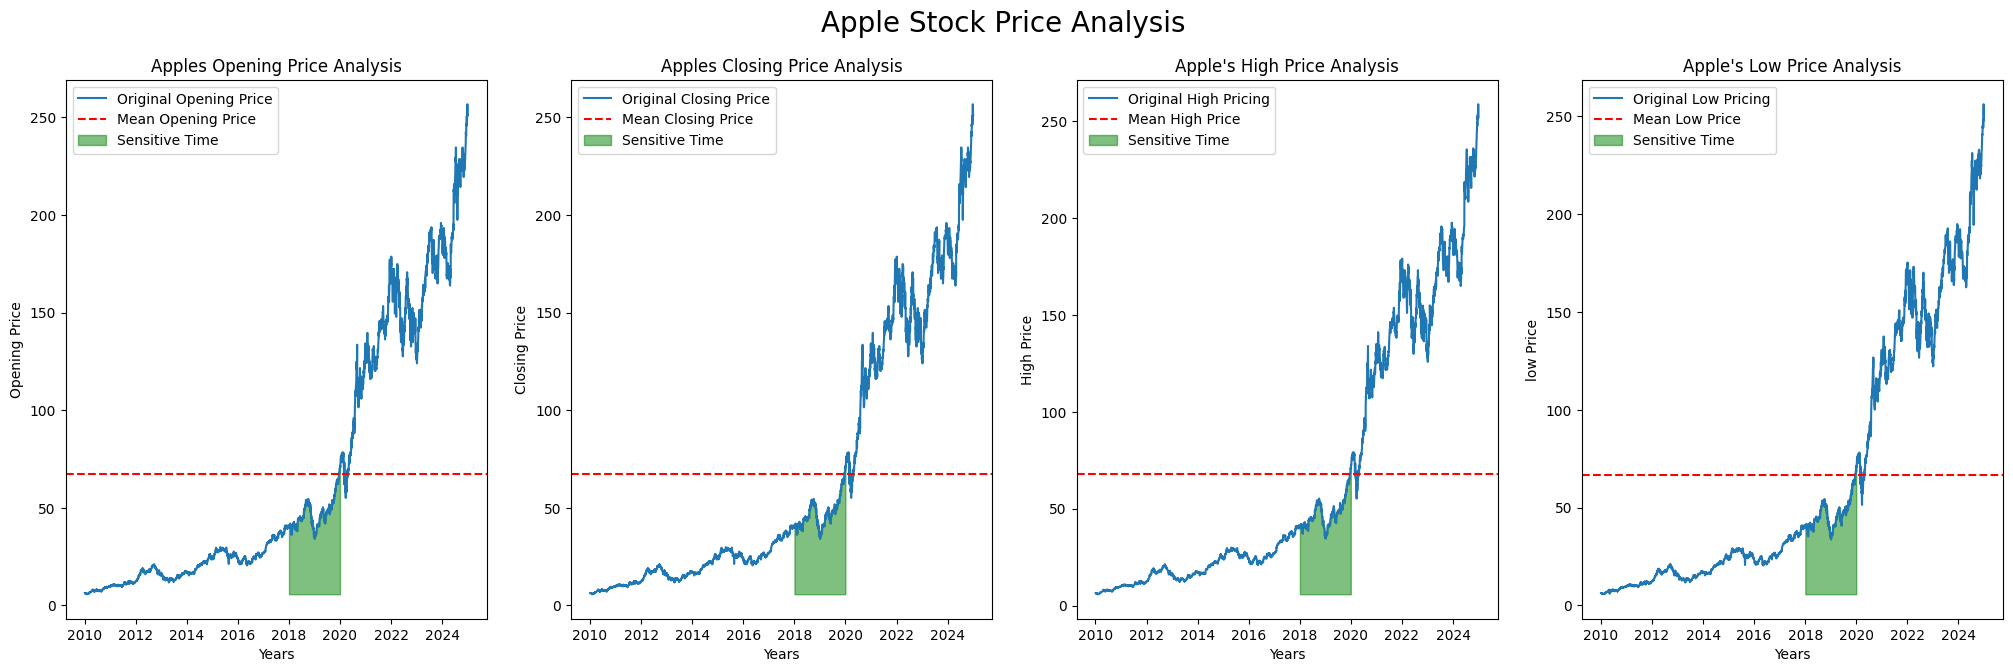

In [69]:
df1['Close'] = pd.to_numeric(df1['Close'], errors = 'coerce')
df1['Close'] = df1['Close'].round(2)
df1['Open'] = pd.to_numeric(df1['Open'], errors = 'coerce')
df1['Close'] = df1['Open'].round(2)
df1['High'] = pd.to_numeric(df1['High'], errors = 'coerce')
df1['High'] = df1['High'].round(2)
df1['Low'] = pd.to_numeric(df1['Low'], errors= 'coerce')
df1['Low'] = df1['Low'].round(2)

mask_apple = ((df1['Date'] >= "2018-01-01" ) & (df1['Date'] <= "2020-01-01"))

x_close = df1['Close'].values
y_apple = df1['Date'].values
x_close_mean = df1['Close'].values.mean()
y_min_close = min(x_close)

x_open = df1['Open'].values
x_open_mean = df1['Open'].values.mean()
y_min_open = min(x_open)

x_high = df1['High'].values
x_high_mean = x_high.mean()
y_min_high = min(x_high)

x_low = df1['Low'].values
x_low_mean = x_low.mean()
y_min_low = min(x_low)




plt.figure(figsize=(25,7))
plt.suptitle("Apple Stock Price Analysis", fontsize = 20 )

plt.subplot(1,4,1)
plt.plot(y_apple, x_open, label = "Original Opening Price")
plt.axhline(x_close_mean, color = 'r', linestyle ='--', label = "Mean Opening Price")
plt.fill_between(
    y_apple, x_open,
    y_min_open,
    where=mask_apple,
    color = 'g',
    alpha= 0.5,
    label = "Sensitive Time"
    
)
plt.title("Apples Opening Price Analysis")
plt.xlabel('Years')
plt.ylabel("Opening Price")
plt.legend()


plt.subplot(1,4,2)
plt.plot(y_apple,x_close, label = "Original Closing Price")
plt.axhline(x_open_mean, color = 'r', linestyle = '--', label = "Mean Closing Price")
plt.fill_between(
    y_apple, x_close,
    y_min_open,
    where =mask_apple,
    color = 'g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.title("Apples Closing Price Analysis")
plt.xlabel('Years')
plt.ylabel("Closing Price")
plt.legend()

plt.subplot(1,4,3)
plt.plot(y_apple,x_high, label = "Original High Pricing" )
plt.axhline(x_high_mean, color = 'r', linestyle = '--', label = "Mean High Price")
plt.fill_between(
    y_apple, x_high,
    y_min_high,
    where= mask_apple,
    color='g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.title("Apple's High Price Analysis")
plt.xlabel('Years')
plt.ylabel("High Price")
plt.legend()

plt.subplot(1,4,4)
plt.plot(y_apple, x_low, label="Original Low Pricing")
plt.axhline(x_low_mean, color = 'r', linestyle = '--', label = "Mean Low Price")
plt.fill_between(
    y_apple,x_low,
    y_min_low,
    where = mask_apple,
    color ='g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.title("Apple's Low Price Analysis")
plt.xlabel('Years')
plt.ylabel("low Price")
plt.legend()
plt.show()

In [70]:
df2 = pd.read_csv("data/TESLA.csv")
df2 = df2.rename(columns={'Price':'Date'})
df2.isnull().sum()

df2.drop_duplicates()
df2.reset_index(inplace = True, drop = True)
df2['Date'] = pd.to_datetime(df1['Date'], errors = 'coerce')
df2['Close'] = pd.to_numeric(df2['Close'], errors= 'coerce').round(2)
df2['Open'] = pd.to_numeric(df2['Open'], errors = 'coerce').round(2)
df2['High'] = pd.to_numeric(df2['High'], errors = 'coerce').round(2)
df2['Low'] = pd.to_numeric(df2['Low'], errors = 'coerce').round(2)
df2['Volume'] = pd.to_numeric(df2['Volume'], errors= 'coerce').round(2)



df2 = df2.dropna(subset=['Date'])
df2 = df2.dropna(subset=['Close'])
df2 = df2.dropna(subset=['Open'])
df2 = df2.dropna(subset=['High'])
df2 = df2.dropna(subset=['Low'])
df2 = df2.dropna(subset=['Volume'])

df2

,Date,Close,High,Low,Open,Volume
2,2010-01-05,1.59,1.67,1.17,1.27,281494500.0
3,2010-01-06,1.59,2.03,1.55,1.72,257806500.0
4,2010-01-07,1.46,1.73,1.35,1.67,123282000.0
5,2010-01-08,1.28,1.54,1.25,1.53,77097000.0
6,2010-01-11,1.07,1.33,1.06,1.33,103003500.0
...,...,...,...,...,...,...
3649,2024-07-03,462.28,462.78,435.14,435.90,59551800.0
3650,2024-07-05,454.13,465.33,451.02,465.16,76366400.0
3651,2024-07-08,431.66,450.00,426.50,449.52,82666800.0
3652,2024-07-09,417.41,427.00,415.75,419.40,64941000.0


In [71]:
x_close = df2['Close'].values
x_close_mean = x_close.mean()
y_min_close = min(x_close)
x_open = df2['Open'].values
x_open_mean = x_close.mean()

x_high = df2['High'].values
x_high_mean = x_high.mean()

x_low = df2['Low'].values
x_low_mean = x_low.mean()

x_volume = df2['Volume'].values
x_volume_mean = x_volume.mean()

y_tesla = df2['Date'].values
mask_tesla = ((df2['Date'] >= "2018-01-01") & (df2['Date'] <= "2020-01-01"))




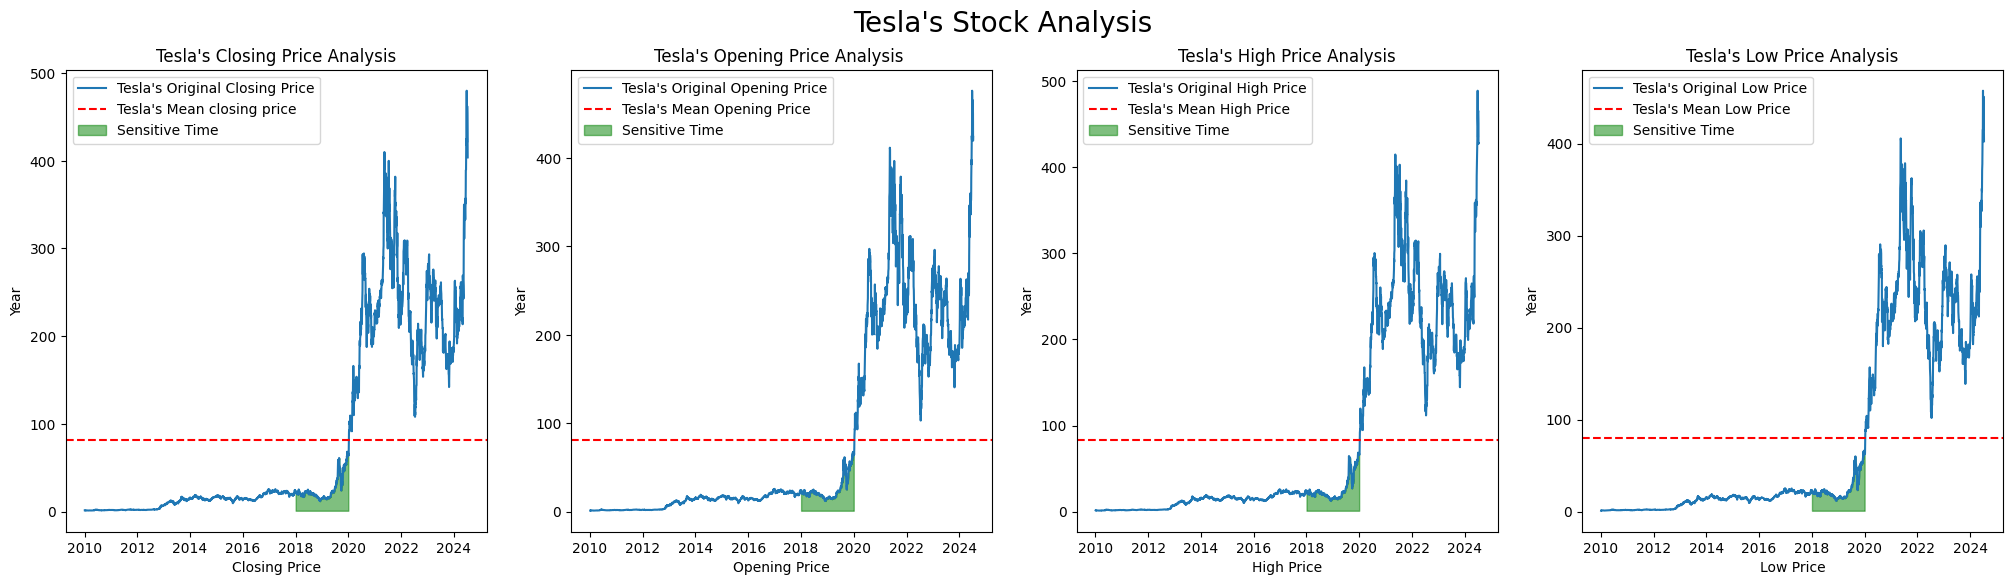

In [ ]:
plt.figure(figsize=(25,6))

plt.suptitle("Tesla's Stock Analysis", fontsize = 20)

plt.subplot(1,4,1)
plt.plot(y_tesla, x_close, label= "Tesla's Original Closing Price")
plt.axhline(x_close_mean, color = 'r',linestyle ='--', label = "Tesla's Mean closing price")
plt.fill_between(
    y_tesla,x_close,
    y_min_close,
    where=mask_tesla,
    color = 'g',
    alpha = 0.5,
    label = "Sensitive Time"
)
plt.legend()
plt.xlabel('Closing Price')
plt.ylabel('Year')
plt.title("Tesla's Closing Price Analysis")


plt.subplot(1,4,2)
plt.plot(y_tesla, x_open, label = "Tesla's Original Opening Price")
plt.axhline(x_open_mean, color ='r',linestyle = '--', label = "Tesla's Mean Opening Price")
plt.fill_between(
    y_tesla,x_open,
    min(x_open),
    where=mask_tesla,
    color='g',
    alpha =0.5,
    label = "Sensitive Time"

)
plt.title("Tesla's Opening Price Analysis ")
plt.xlabel('Opening Price')
plt.ylabel('Year')
plt.legend()


plt.subplot(1,4,3)
plt.plot(y_tesla, x_high, label = "Tesla's Original High Price")
plt.axhline(x_high_mean, color = 'r', linestyle = '--', label = "Tesla's Mean High Price")
plt.fill_between(
    y_tesla,x_high,
    min(x_high),
    where = mask_tesla,
    color = 'g',
    alpha = 0.5,
    label = "Sensitive Time"
)
plt.title("Tesla's High Price Analysis")
plt.xlabel('High Price')
plt.ylabel('Year')
plt.legend()

plt.subplot(1,4,4)
plt.plot(y_tesla,x_low, label= "Tesla's Original Low Price")
plt.axhline(x_low_mean, color = 'r',linestyle = '--', label = "Tesla's Mean Low Price")
plt.fill_between(
    y_tesla, x_low,
    min(x_low),
    where=mask_tesla,
    color = 'g',
    alpha = 0.5,
    label = "Sensitive Time"

)
plt.title("Tesla's Low Price Analysis")
plt.xlabel('Low Price')
plt.ylabel('Year')
plt.legend()

# plt.subplot(1,5,5)
# plt.plot(y_tesla, x_volume, label = "Tesla's Original Volume Price")
# plt.axhline(x_volume_mean, color ='r', linestyle = '--', label ="Tesla's Volume Price")
# plt.fill_between(
#     y_tesla , x_volume,
#     min(x_volume),
#     where=mask_tesla,
#     color = 'g',
#     alpha = 0.5,
#     label = "Sensitive Time"

# )
# plt.title("Tesla's Stock Volume Analysis")
# plt.xlabel("Volume")
# plt.ylabel("Year")
# plt.legend()

plt.show()

plt.figure(figsize=(25,7))
plt.plot(y_tesla, x_volume, label = "Tesla's Original Volume Price")
plt.axhline(x_volume_mean, color ='r', linestyle = '-', label ="Tesla's Volume Price")
plt.fill_between(
    y_tesla , x_volume,
    min(x_volume),
    where=mask_tesla,
    color = 'g',
    alpha = 0.5,
    label = "Sensitive Time"

)
plt.title("Tesla's Stock Volume Analysis")
plt.xlabel("Volume")
plt.ylabel("Year")
plt.legend()




In [ ]:
df_e = pd.read_csv("data/Unemployment.csv")
df_e = df_e.rename(columns={'UNRATE' : 'une_rate'})
df_e = df_e.rename(columns={'DATE':'date'})
df_e['date'] = pd.to_datetime(df_e['date'])
df_e.dropna(subset=['date'])
df_e.dropna(subset=['une_rate'])
df_e

,date,une_rate
0,2010-01-01,9.8
1,2010-02-01,9.8
2,2010-03-01,9.9
3,2010-04-01,9.9
4,2010-05-01,9.6
...,...,...
176,2024-09-01,4.1
177,2024-10-01,4.1
178,2024-11-01,4.2
179,2024-12-01,4.1


In [ ]:
df_e.describe()

,date,une_rate
count,181,181.000000
mean,2017-07-01 13:07:37.458563584,5.787293
min,2010-01-01 00:00:00,3.400000
25%,2013-10-01 00:00:00,3.900000
50%,2017-07-01 00:00:00,5.000000
75%,2021-04-01 00:00:00,7.500000
max,2025-01-01 00:00:00,14.800000
std,NaN,2.235497


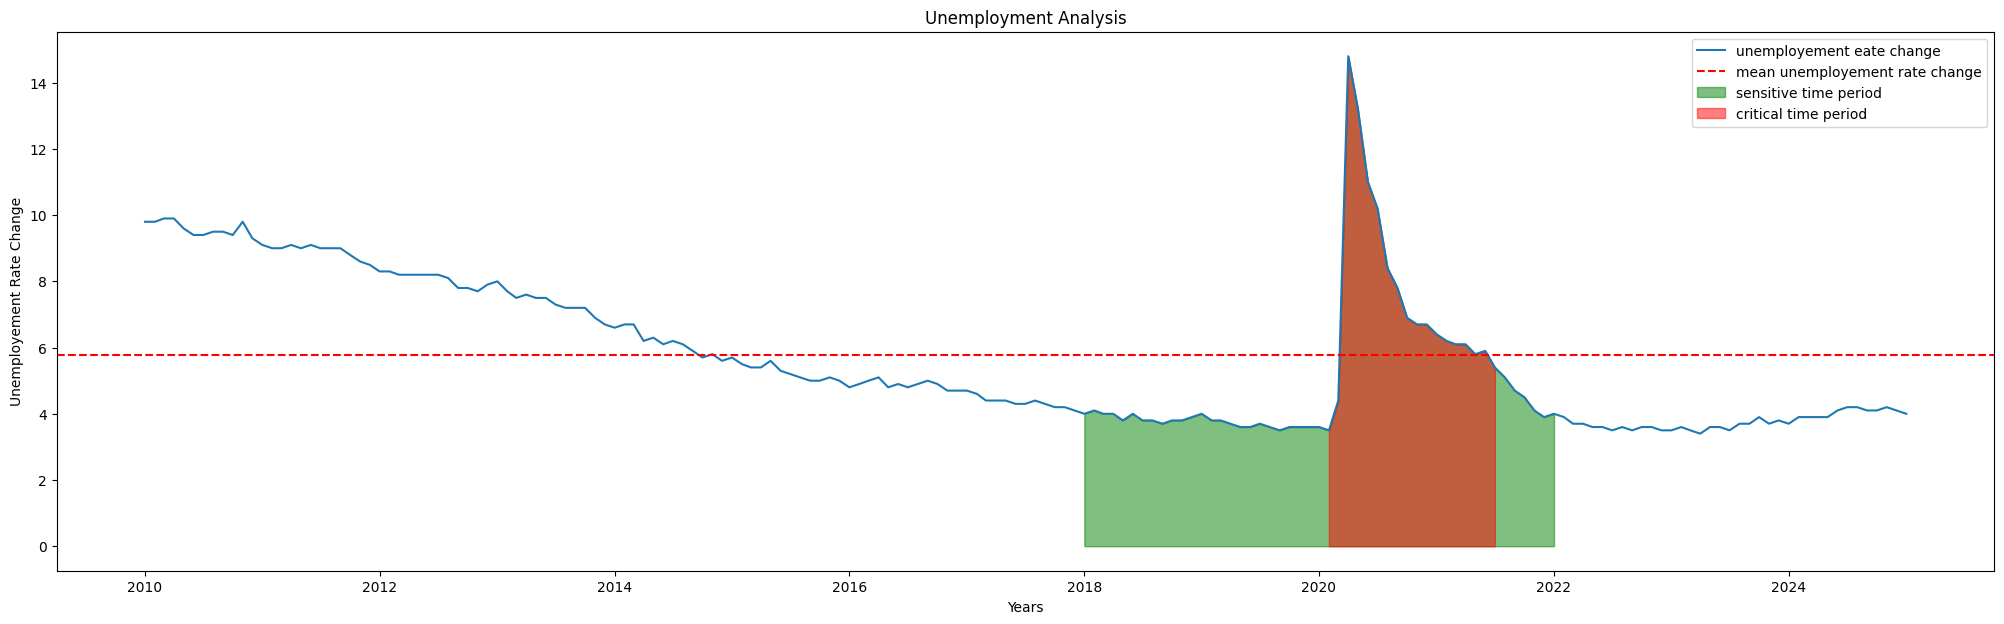

In [ ]:
# df_e = pd.to_numeric(df_e['une_rate'])
x_e = df_e['une_rate'].values
y_e = df_e['date'].values

x_e_mean = x_e.mean()
y_e_min = min(y_e)

mask_e = ((df_e['date'] >= '2018-01-01') & (df_e['date'] <= '2022-01-01')) 
mask_e_1 = ((df_e['date'] >= '2020-02-01') & (df_e['date'] <= '2021-07-01'))

plt.figure(figsize=(25,7))
plt.plot(y_e, x_e, label="unemployement eate change")
plt.axhline(x_e_mean, color='r', linestyle = '--', label ="mean unemployement rate change")
plt.fill_between(
    y_e,x_e,
   
    where=mask_e,
    color = 'g',
    alpha = 0.5,
    label = "sensitive time period"

)

plt.fill_between(
    y_e,x_e,
    where = mask_e_1,
    color = 'r',
    alpha = 0.5,
    label = "critical time period"

)
plt.title("Unemployment Analysis")
plt.xlabel("Years")
plt.ylabel("Unemployement Rate Change")
plt.legend()
plt.show()


In [ ]:
df500 = pd.read_csv("data/S&P500.csv")
df500 = df500.rename(columns={'Price':'Date'})
df500['Date'] = pd.to_datetime(df500['Date'], format = '%Y-%m-%d', errors = 'coerce')
df500.dropna(subset=['High'])
df500.dropna(subset=['Low'])
df500.dropna(subset=['Open'])
df500.dropna(subset=['Close'])
df500 = df500.drop_duplicates()
df500 = df500.replace("",np.nan)

df500['Close'] = pd.to_numeric(df500['Close'], errors='coerce').round(2)
df500['High'] = pd.to_numeric(df500['High'], errors = 'coerce').round(2)
df500['Low'] = pd.to_numeric(df500['Low'], errors='coerce').round(2)
df500['Open'] = pd.to_numeric(df500['Open'], errors = 'coerce').round(2)
df500['Volume'] = pd.to_numeric(df500['Volume'], errors='coerce').round(2)

print(df500.isnull().sum())
print(df500.isna().sum())

# df500
# print(df500.dtypes)
# df500 = df500.dropna()


Date      2
Close     2
High      2
Low       2
Open      2
Volume    2
dtype: int64
Date      2
Close     2
High      2
Low       2
Open      2
Volume    2
dtype: int64


In [ ]:
print(df500.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [ ]:
import numpy as np

df500 = df500.replace("", np.nan)
df500 = df500.dropna()
df500 = df500.sort_values('Date')
df500 = df500.reset_index(drop=True)

In [ ]:
df500

,Date,Close,High,Low,Open,Volume
0,2010-01-04,1132.99,1133.87,1116.56,1116.56,3.991400e+09
1,2010-01-05,1136.52,1136.63,1129.66,1132.66,2.491020e+09
2,2010-01-06,1137.14,1139.19,1133.95,1135.71,4.972660e+09
3,2010-01-07,1141.69,1142.46,1131.32,1136.27,5.270680e+09
4,2010-01-08,1144.98,1145.39,1136.22,1140.52,4.389590e+09
...,...,...,...,...,...,...
3769,2024-12-24,6040.04,6040.10,5981.44,5984.63,1.757720e+09
3770,2024-12-26,6037.59,6049.75,6007.37,6024.97,2.904530e+09
3771,2024-12-27,5970.84,6006.17,5932.95,6006.17,3.159610e+09
3772,2024-12-30,5906.94,5940.79,5869.16,5920.67,3.433250e+09


In [ ]:
x_500_o = df500['Open'].values
x_500_o_mean = x_500_o.mean()
y_500_o_min = min(x_500_o)

x_500_c = df500['Close'].values
x_500_c_mean = x_500_c.mean()
y_500_c_min = min(x_500_c)

x_500_h = df500['High'].values
x_500_h_mean  = x_500_h.mean()
y_500_h_min = min(x_500_h)

x_500_l = df500['Low'].values
x_500_l_mean = x_500_l.mean()
y_500_l_min = min(x_500_l)

x_500_v = df500['Volume'].values
x_500_v_mean = x_500_v.mean()
y_500_v_min = min(x_500_v)

mask_500 = ((df500['Date'] >= '2018-01-01') & (df500['Date'] <= '2020-01-01'))

y_500 = df500['Date'].values





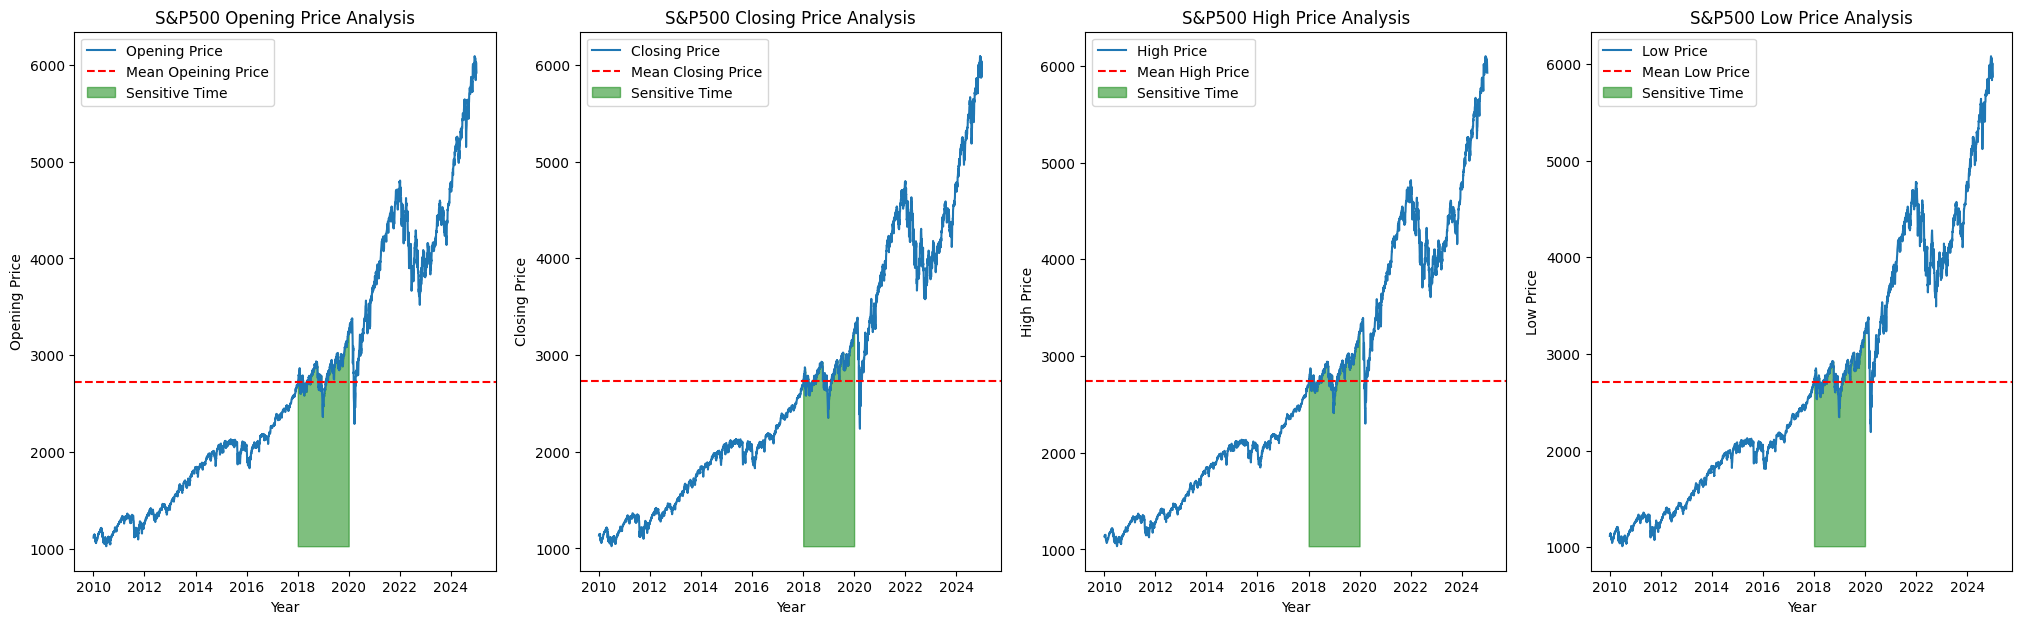

In [ ]:
plt.figure(figsize=(25,7))

plt.subplot(1,4,1)
plt.plot(y_500,x_500_o,label ='Opening Price')
plt.axhline(x_500_o_mean, color='r',linestyle ='--',label = 'Mean Opeining Price')
plt.fill_between(
    y_500, x_500_o,
    y_500_o_min,
    where=mask_500,
    color ='g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.legend()
plt.title('S&P500 Opening Price Analysis')
plt.xlabel('Year')
plt.ylabel('Opening Price')

plt.subplot(1,4,2)
plt.plot(y_500,x_500_c,label ='Closing Price')
plt.axhline(x_500_c_mean, color='r',linestyle ='--',label = 'Mean Closing Price')
plt.fill_between(
    y_500, x_500_c,
    y_500_c_min,
    where=mask_500,
    color ='g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.legend()
plt.title('S&P500 Closing Price Analysis')
plt.xlabel('Year')
plt.ylabel('Closing Price')

plt.subplot(1,4,3)
plt.plot(y_500,x_500_h,label ='High Price')
plt.axhline(x_500_h_mean, color='r',linestyle ='--',label = 'Mean High Price')
plt.fill_between(
    y_500, x_500_h,
    y_500_h_min,
    where=mask_500,
    color ='g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.legend()

plt.title('S&P500 High Price Analysis')
plt.xlabel('Year')
plt.ylabel('High Price')

plt.subplot(1,4,4)
plt.plot(y_500,x_500_l,label ='Low Price')
plt.axhline(x_500_l_mean, color='r',linestyle ='--',label = 'Mean Low Price')
plt.fill_between(
    y_500, x_500_l,
    y_500_l_min,
    where=mask_500,
    color ='g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.legend()
plt.title('S&P500 Low Price Analysis')
plt.xlabel('Year')
plt.ylabel('Low Price')
plt.show()

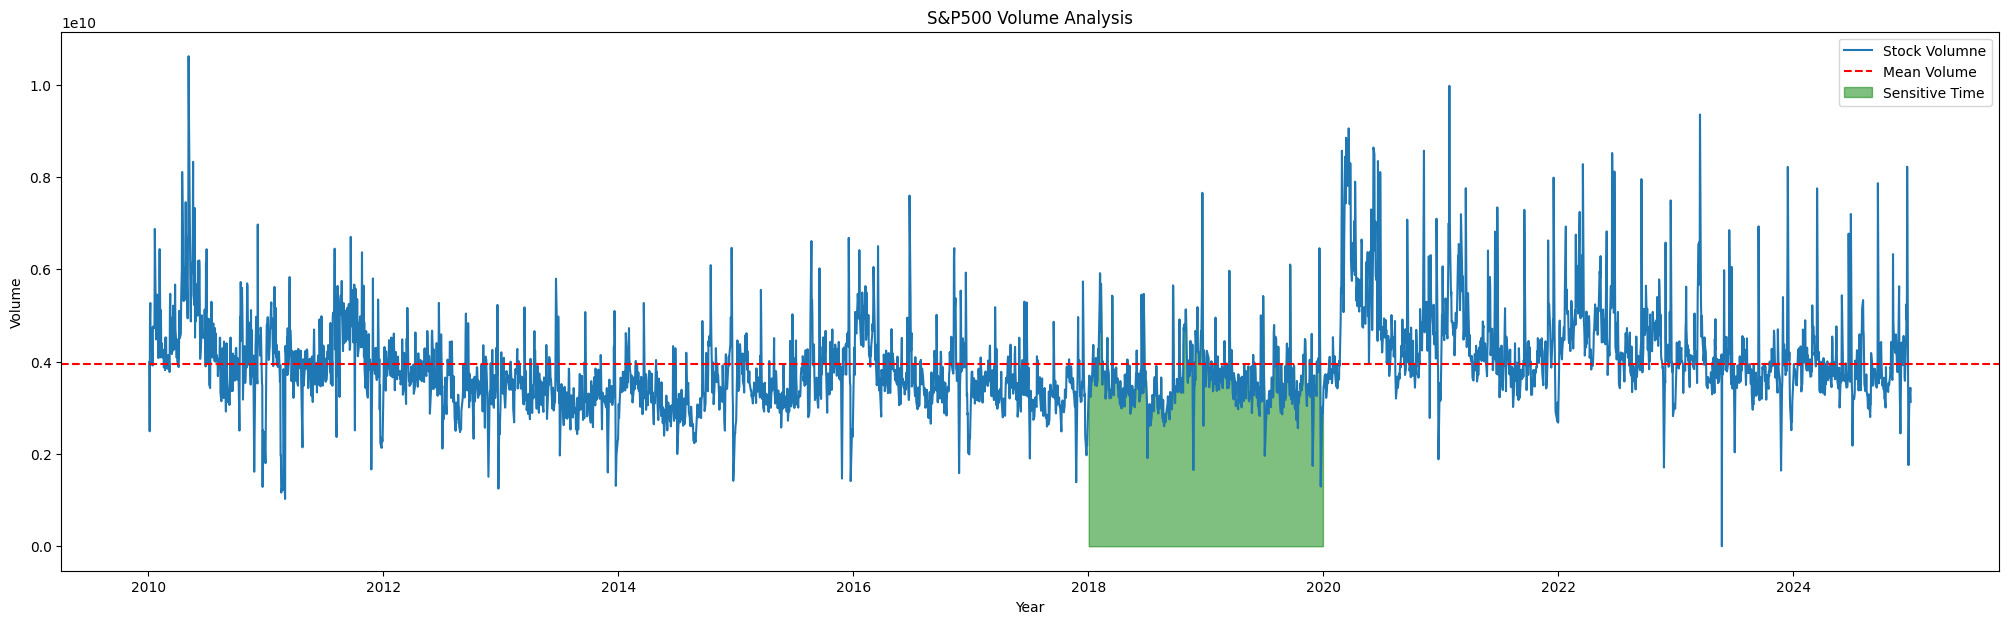

In [ ]:
plt.figure(figsize=(25,7))

plt.plot(y_500,x_500_v,label ='Stock Volumne')
plt.axhline(x_500_v_mean, color='r',linestyle ='--',label = 'Mean Volume')
plt.fill_between(
    y_500, x_500_v,
    y_500_v_min,
    where=mask_500,
    color ='g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.legend()
plt.title('S&P500 Volume Analysis')
plt.xlabel('Year')
plt.ylabel('Volume')
plt.show()

In [ ]:
sensex = pd.read_csv('data/SENSEX.csv')
sensex = sensex.rename(columns={'Price':'Date'})
sensex['Date'] = pd.to_datetime(sensex['Date'], format="%Y-%m-%d", errors= 'coerce')
print(sensex.columns)
sensex.dropna(subset=['High'])
sensex.dropna(subset=['Low'])
sensex.dropna(subset=['Open'])
sensex.dropna(subset=['Close'])
sensex.dropna(subset=['Volume'])

sensex['Close'] = pd.to_numeric(sensex['Close'], errors = 'coerce').round(2)
sensex['High'] = pd.to_numeric(sensex['High'], errors='coerce').round(2)
sensex['Low'] = pd.to_numeric(sensex['Low'], errors= 'coerce').round(2)
sensex['Open'] = pd.to_numeric(sensex['Open'], errors='coerce').round(2)
sensex['Volume'] = pd.to_numeric(sensex['Volume'], errors = 'coerce')

sensex = sensex.replace("", np.nan)
sensex = sensex.dropna()
sensex = sensex.sort_values('Date')
sensex = sensex.reset_index(drop=True)
sensex = sensex.drop_duplicates()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [ ]:
sensex

,Date,Close,High,Low,Open,Volume
0,2010-01-04,17558.73,17582.84,17378.38,17473.45,28200.0
1,2010-01-05,17686.24,17729.78,17555.77,17555.77,27000.0
2,2010-01-06,17701.13,17790.33,17636.71,17719.47,21400.0
3,2010-01-07,17615.72,17733.34,17566.54,17701.97,18000.0
4,2010-01-08,17540.29,17658.12,17508.96,17603.87,17200.0
...,...,...,...,...,...,...
3681,2024-12-24,78472.87,78877.36,78397.79,78707.37,6200.0
3682,2024-12-26,78472.48,78898.37,78173.38,78557.28,5600.0
3683,2024-12-27,78699.07,79043.15,78598.55,78607.62,7700.0
3684,2024-12-30,78248.13,79092.70,78077.13,78637.58,8900.0


In [ ]:
x_sen_o = sensex['Open'].values
x_sen_o_mean = x_sen_o.mean()
y_sen_o_min = min(x_sen_o)

x_sen_c = sensex['Close'].values
x_sen_c_mean = x_sen_c.mean()
y_sen_c_min = min(x_sen_c)

x_sen_h = sensex['High'].values
x_sen_h_mean = x_sen_h.mean()
y_sen_h_min = min(x_sen_h)

x_sen_l = sensex['Low'].values
x_sen_l_mean = x_sen_l.mean()
y_sen_l_min = min(x_sen_l)

x_sen_v = sensex['Volume'].values
x_sen_v_mean = x_sen_v.mean()
y_sen_v_min = min(x_sen_v)

mask_sensex = ((sensex['Date'] >= '2018-01-01') & (sensex['Date'] <= '2020-01-01'))
y_sen = sensex['Date'].values

# x_sen_v = sensex['Volume'][mask_sensex].values
# x_sen_v_mean = x_sen_v.mean()
# y_sen_v_min = min(x_sen_v)

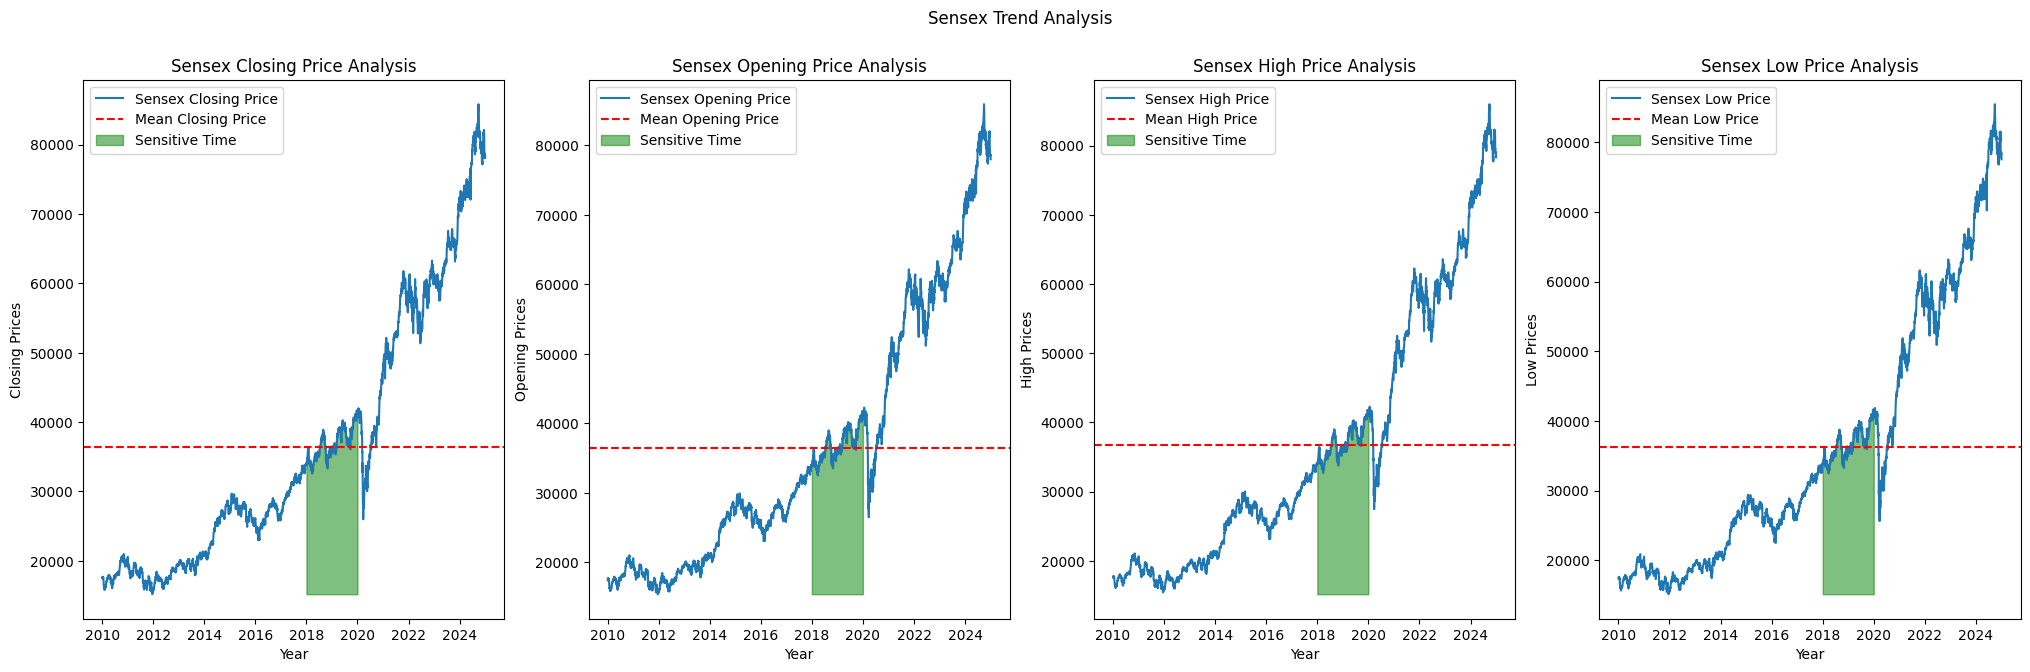

In [ ]:
plt.figure(figsize=[25,7])
plt.suptitle("Sensex Trend Analysis")

plt.subplot(1,4,1)
plt.plot(y_sen,x_sen_c,label = 'Sensex Closing Price')
plt.axhline(x_sen_c_mean, color = 'r', linestyle ='--',label ='Mean Closing Price')
plt.fill_between(
    y_sen,x_sen_c,
    y_sen_c_min,
    where = mask_sensex,
    color = 'g',
    alpha = 0.5,
    label = 'Sensitive Time'
)

plt.title('Sensex Closing Price Analysis')
plt.xlabel('Year')
plt.ylabel('Closing Prices')
plt.legend()


plt.subplot(1,4,2)
plt.plot(y_sen,x_sen_o,label = 'Sensex Opening Price')
plt.axhline(x_sen_o_mean, color = 'r', linestyle ='--',label ='Mean Opening Price')
plt.fill_between(
    y_sen,x_sen_o,
    y_sen_o_min,
    where = mask_sensex,
    color = 'g',
    alpha = 0.5,
    label = 'Sensitive Time'
)

plt.title('Sensex Opening Price Analysis')
plt.xlabel('Year')
plt.ylabel('Opening Prices')
plt.legend()


plt.subplot(1,4,3)
plt.plot(y_sen,x_sen_h,label = 'Sensex High Price')
plt.axhline(x_sen_h_mean, color = 'r', linestyle ='--',label ='Mean High Price')
plt.fill_between(
    y_sen,x_sen_h,
    y_sen_c_min,
    where = mask_sensex,
    color = 'g',
    alpha = 0.5,
    label = 'Sensitive Time'
)

plt.title('Sensex High Price Analysis')
plt.xlabel('Year')
plt.ylabel('High Prices')
plt.legend()


plt.subplot(1,4,4)
plt.plot(y_sen,x_sen_l,label = 'Sensex Low Price')
plt.axhline(x_sen_l_mean, color = 'r', linestyle ='--',label ='Mean Low Price')
plt.fill_between(
    y_sen,x_sen_l,
    y_sen_l_min,
    where = mask_sensex,
    color = 'g',
    alpha = 0.5,
    label = 'Sensitive Time'
)

plt.title('Sensex Low Price Analysis')
plt.xlabel('Year')
plt.ylabel('Low Prices')
plt.legend()


plt.show()

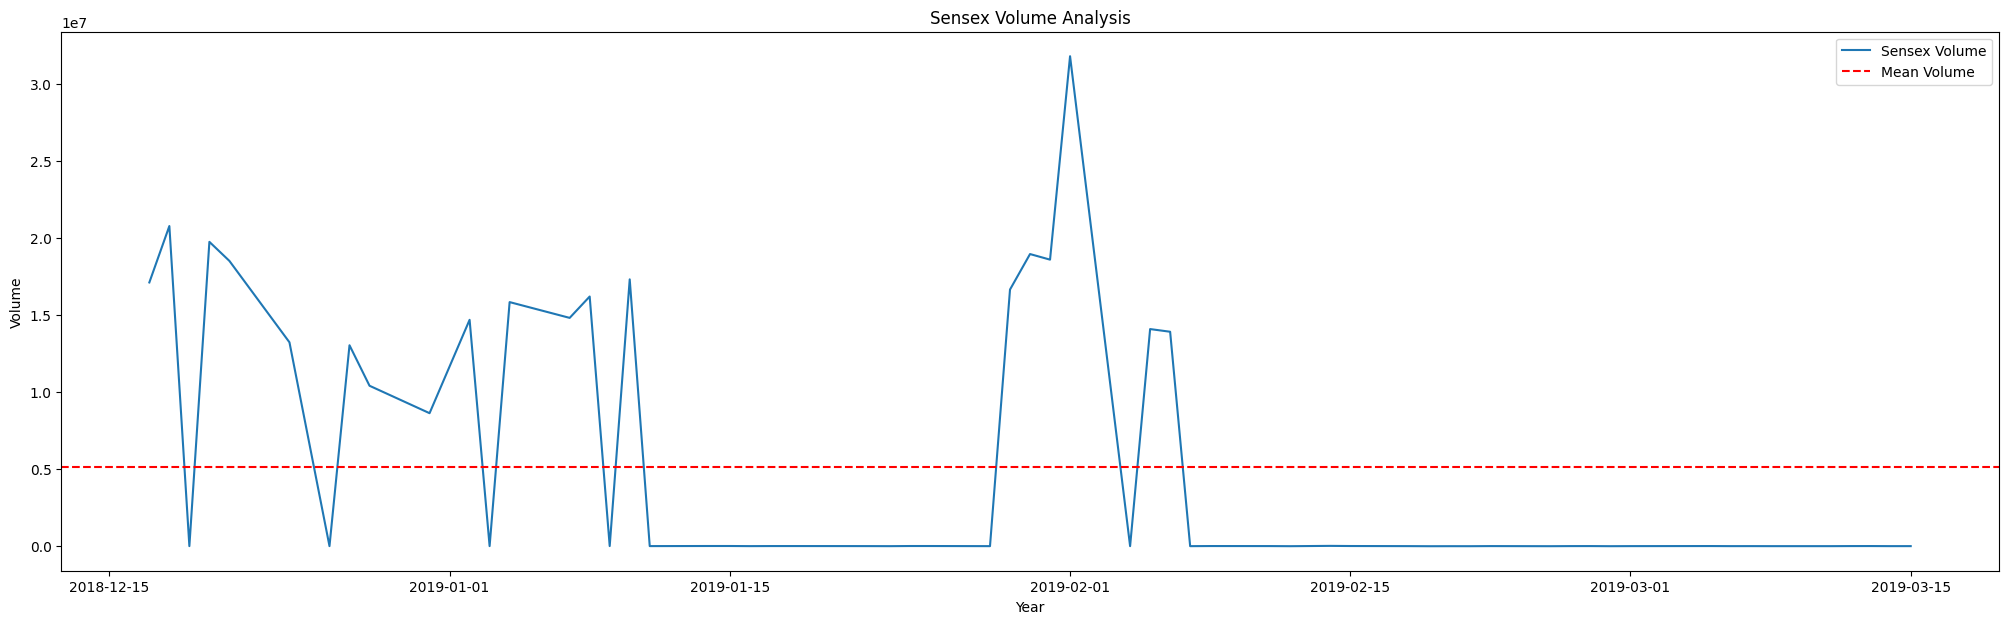

In [ ]:
plt.figure(figsize=[25,7])

mask_sensex_volume = ((sensex['Date'] >= "2018-12-15") & (sensex['Date'] <= "2019-03-15"))

x_sen_v_mean = x_sen_v[mask_sensex_volume].mean()


plt.plot(y_sen[mask_sensex_volume],x_sen_v[mask_sensex_volume],label = 'Sensex Volume')
plt.axhline(x_sen_v_mean, color = 'r', linestyle ='--',label ='Mean Volume')
# plt.fill_between(
#     y_sen[mask_sensex_volume],x_sen_v[mask_sensex_volume],
#     # where = mask_sensex,
#     y_sen_v_min,
#     color = 'g',
#     alpha = 0.5,
#     label = 'Sensitive Time'
# )

plt.title('Sensex Volume Analysis')
plt.xlabel('Year')
plt.ylabel('Volume')
plt.legend()


plt.show()